<a href="https://colab.research.google.com/github/matheusmello-o/turnover-optmization/blob/main/turnover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
!pip install pycm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 11.8 MB/s eta 0:00:00


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://github.com/matheusmello-o/turnover-optmization/raw/main/files/Base_dados%20-%20Rotatividade%20RH.xlsx'


df = pd.read_excel(url, engine='openpyxl')
df.columns = df.columns.str.lower()
df.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento
0,2024-02-14,NaT,3,24,2.066788,2.043644,Pleno,4994.41,15.465241,0
1,2023-11-16,2024-05-14,6,43,3.256257,1.711719,Sênior,8798.34,19.036627,1
2,2023-11-16,NaT,6,45,4.827732,3.480214,Sênior,8891.02,13.326408,0
3,2023-05-20,NaT,12,31,1.453944,1.617558,Pleno,7606.22,14.209663,0
4,2022-07-24,NaT,22,37,2.088917,2.763390,Sênior,9236.03,11.059687,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_contratacao      650 non-null    datetime64[ns]
 1   data_desligamento     144 non-null    datetime64[ns]
 2   meses_de_servico      650 non-null    int64         
 3   idade                 650 non-null    int64         
 4   pontuacao_desempenho  650 non-null    float64       
 5   satisfacao_trabalho   650 non-null    float64       
 6   nivel_cargo           650 non-null    object        
 7   salario               650 non-null    float64       
 8   horas_extras          650 non-null    float64       
 9   desligamento          650 non-null    int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(1)
memory usage: 50.9+ KB


In [ ]:
df.describe()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,salario,horas_extras,desligamento
count,650,144,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000
mean,2022-10-31 06:38:46.153846272,2024-05-14 00:00:00,18.690769,28.349231,3.027463,2.940577,6131.587062,10.098864,0.221538
min,2021-06-29 00:00:00,2024-05-14 00:00:00,3.000000,18.000000,1.000242,1.002868,2004.500000,0.003734,0.000000
25%,2022-02-24 00:00:00,2024-05-14 00:00:00,10.000000,22.000000,1.988753,1.968571,4023.752500,4.978000,0.000000
50%,2022-10-22 00:00:00,2024-05-14 00:00:00,19.000000,27.000000,3.058911,2.923458,5562.950000,9.413546,0.000000
75%,2023-07-19 00:00:00,2024-05-14 00:00:00,27.000000,33.000000,4.022709,3.964356,7814.480000,14.749310,0.000000
max,2024-02-14 00:00:00,2024-05-14 00:00:00,35.000000,49.000000,4.992102,4.999415,11957.290000,41.638350,1.000000
std,NaN,NaN,9.652262,8.014983,1.174226,1.148514,2689.075566,6.242406,0.415602


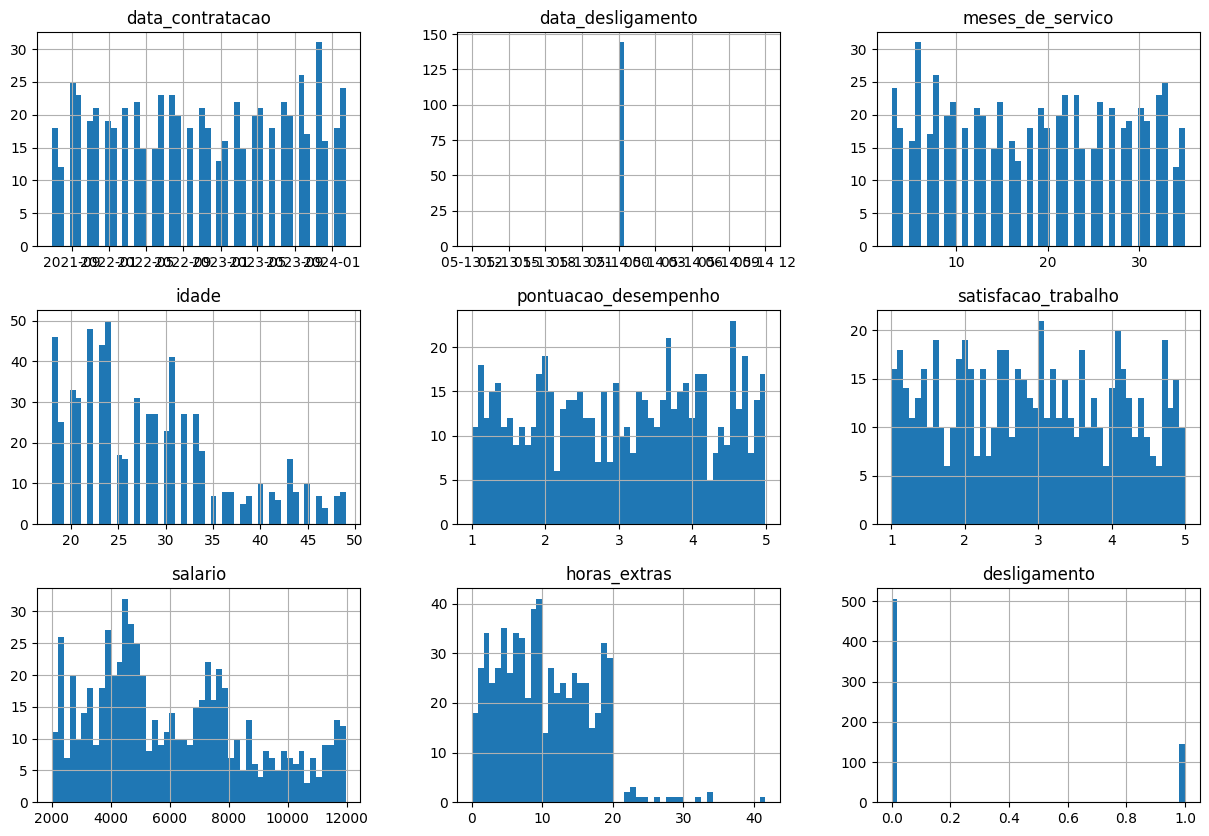

In [ ]:
df.hist(bins = 50, figsize=(15, 10))
plt.show()

## <font color = 'salmon'> General Metrics </font>

In [ ]:
# quantidade de pessoas desligadas
# quantidade de pessoas contratadas

total_colaboradores = df.shape[0]
desligamentos = df.desligamento.sum()
colaboradores_ativos = total_colaboradores - desligamentos
turnover = ((total_colaboradores + desligamentos) / 2) / colaboradores_ativos

print('Taxa de turnover:', turnover)
print('Pessoas ativas: ', colaboradores_ativos)
print('Pessoas desligadas: ', desligamentos)

Taxa de turnover: 0.7845849802371542
Pessoas ativas:  506
Pessoas desligadas:  144


# <font color = 'gold'> Separating Train and Test datasets </font>

In [36]:
def strat_func(df, version):
    from sklearn.model_selection import StratifiedShuffleSplit
    random_state = 42

    df = df.copy()

    if version == 1:
        bins = [0, 1, 2, 3, 4, np.inf]
        labels = [1, 2, 3, 4, 5]
        df['pontuacao_desempenho_cat'] = pd.cut(x = df.pontuacao_desempenho,
                                                bins = bins,
                                                labels = labels)

        bins = [0, 1, 2, 3, 4, np.inf]
        labels = [1, 2, 3, 4, 5]
        df['satisfacao_trabalho_cat'] = pd.cut(x = df.satisfacao_trabalho,
                                                bins = bins,
                                                labels = labels)


        df['combined'] = df.apply(lambda row: f"{row['pontuacao_desempenho_cat']}_{row['satisfacao_trabalho_cat']}", axis = 1)

        shuffle_split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = random_state)

        for train_index, test_index in shuffle_split.split(X = df, y = df.combined):
            train_set = df.loc[train_index]
            test_set = df.loc[test_index]

        train_set.drop(columns = ['pontuacao_desempenho_cat', 'satisfacao_trabalho_cat', 'combined'], inplace = True)
        test_set.drop(columns = ['pontuacao_desempenho_cat', 'satisfacao_trabalho_cat', 'combined'], inplace = True)

        return train_set, test_set

    elif version == 2:
        shuffle_split = StratifiedShuffleSplit(n_splits = 10, test_size = 0.2, random_state = random_state)

        for train_index, test_index in shuffle_split.split(X = df, y = df.desligamento):
            train_set = df.loc[train_index]
            test_set = df.loc[test_index]

        return train_set, test_set

In [39]:
train_set, test_set = strat_func(df, version = 1)

# <font color = 'gold'> Data Exploration </font>

In [41]:
df_train = train_set.copy()

In [42]:
print('Data min de desligamento: ', df_train.data_desligamento.min())
print('Data max de desligamento: ', df_train.data_desligamento.max())

print('Data min de contratacao: ', df_train.data_contratacao.min())
print('Data max de contratacao: ', df_train.data_contratacao.max())

print('\nVerificando se existe algum registro com data de contratacao igual a dada de desligamento')
df_train.loc[df_train.data_desligamento == df_train.data_contratacao].shape

Data min de desligamento:  2024-05-14 00:00:00
Data max de desligamento:  2024-05-14 00:00:00
Data min de contratacao:  2021-06-29 00:00:00
Data max de contratacao:  2024-02-14 00:00:00

Verificando se existe algum registro com data de contratacao igual a dada de desligamento


(0, 10)

<Axes: xlabel='meses_de_servico', ylabel='data_contratacao'>

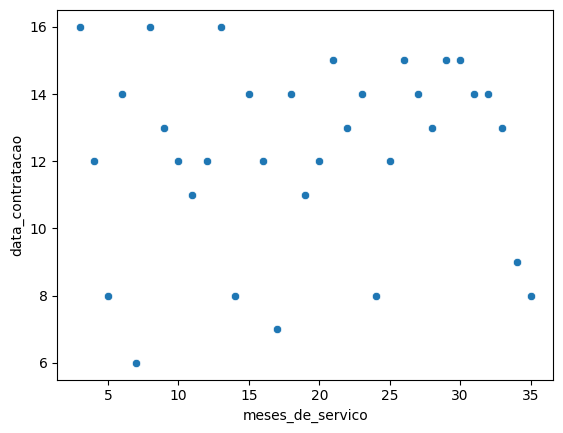

In [43]:
service_fired = df_train.loc[df_train.desligamento == 0].groupby(['meses_de_servico']).data_contratacao.count().reset_index()

sns.scatterplot(data=service_fired,
                x = 'meses_de_servico',
                y = 'data_contratacao')

In [44]:
def taxa_retencao(df_train, by = []):
    total_colaboradores = df_train.shape[0]
    desligamentos = df_train.desligamento.sum()
    colaboradores_ativos = total_colaboradores - desligamentos
    taxa_retencao_geral = colaboradores_ativos / total_colaboradores
    turnover = ((total_colaboradores + desligamentos) / 2) / colaboradores_ativos

    if not by: # checando se a lista está vazia
        return taxa_retencao_geral
    else:
        tx_retencao = df_train.groupby(by, observed=False).agg(total_colaboradores = ('data_contratacao', 'count'),
                              total_desligamentos = ('desligamento', 'sum')).reset_index()

        tx_retencao['colaboradores_ativos'] = tx_retencao.total_colaboradores - tx_retencao.total_desligamentos
        tx_retencao['taxa_retencao'] = tx_retencao.colaboradores_ativos / tx_retencao.total_colaboradores
        tx_retencao['turnover'] = ((tx_retencao.total_colaboradores + tx_retencao.total_desligamentos) / 2) / tx_retencao.colaboradores_ativos
        tx_retencao['comparacao_taxa_geral_turnover'] = (tx_retencao.turnover / turnover - 1) * 100
        return tx_retencao

In [45]:
taxa_retencao(df_train, 'nivel_cargo')

,nivel_cargo,total_colaboradores,total_desligamentos,colaboradores_ativos,taxa_retencao,turnover,comparacao_taxa_geral_turnover
0,Junior,187,46,141,0.754011,0.826241,5.821420
1,Pleno,184,34,150,0.815217,0.726667,-6.931651
2,Sênior,149,34,115,0.771812,0.795652,1.903717


In [46]:
labels = [1, 2, 3, 4]
bins = [0, 25, 30, 35, np.inf]

df_train['idade_group'] = pd.cut(df_train.idade, bins=bins, labels=labels)
df_train.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento,idade_group
505,2021-12-26,NaT,29,24,2.473964,2.533526,Pleno,6052.78,15.373842,0,1
417,2024-01-15,NaT,4,34,3.143208,3.670583,Pleno,7267.31,6.574893,0,3
478,2022-03-26,NaT,26,28,4.229674,3.049479,Pleno,4245.98,0.258354,0,2
519,2022-01-25,NaT,28,29,2.986193,4.516829,Pleno,6865.86,18.580227,0,2
58,2023-10-17,NaT,7,39,3.855709,1.649803,Sênior,7278.08,8.711500,0,4


<Axes: >

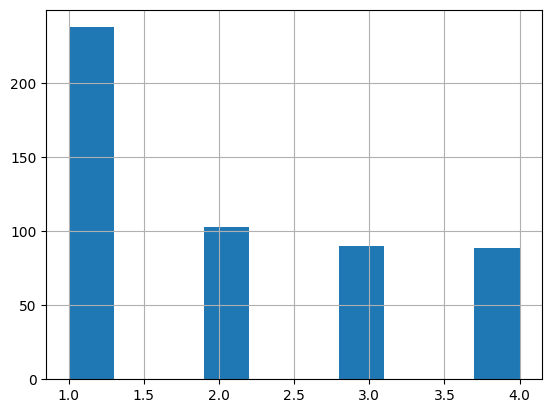

In [47]:
df_train.idade_group.hist()

In [48]:
taxa_retencao(df_train, 'idade_group')

,idade_group,total_colaboradores,total_desligamentos,colaboradores_ativos,taxa_retencao,turnover,comparacao_taxa_geral_turnover
0,1,238,52,186,0.781513,0.779570,-0.156033
1,2,103,21,82,0.796117,0.756098,-3.162268
2,3,90,20,70,0.777778,0.785714,0.630915
3,4,89,21,68,0.764045,0.808824,3.590648


Text(0.5, 1.0, 'Diferença percentual da taxa de turnover geral x por grupo de idade')

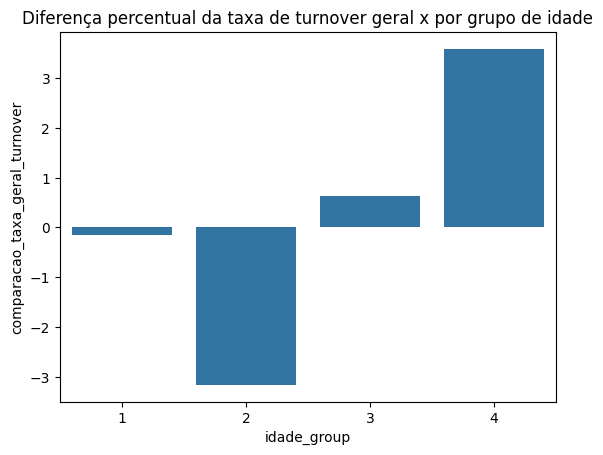

In [49]:
sns.barplot(taxa_retencao(df_train, 'idade_group'),
            x = 'idade_group',
            y = 'comparacao_taxa_geral_turnover')
plt.title('Diferença percentual da taxa de turnover geral x por grupo de idade')

In [ ]:
df_train.meses_de_servico.describe()

count    650.000000
mean      18.690769
std        9.652262
min        3.000000
25%       10.000000
50%       19.000000
75%       27.000000
max       35.000000
Name: meses_de_servico, dtype: float64

<Axes: >

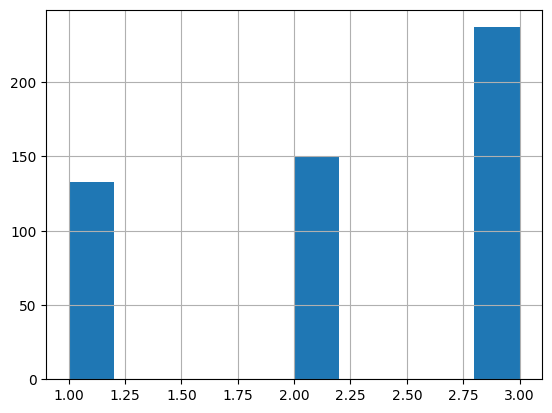

In [50]:
labels = [1, 2, 3]
bins = [0, 10, 20, np.inf]

df_train['meses_de_servico_group'] = pd.cut(x = df_train.meses_de_servico,
                                      bins = bins,
                                      labels = labels)
df_train.meses_de_servico_group.hist()

In [ ]:
taxa_retencao(df_train, by = ['nivel_cargo', 'meses_de_servico_group'])

,nivel_cargo,meses_de_servico_group,total_colaboradores,total_desligamentos,colaboradores_ativos,taxa_retencao,turnover,comparacao_taxa_geral_turnover
0,Junior,1,55,18,37,0.672727,0.986486,26.856240
1,Junior,2,51,11,40,0.784314,0.775000,-0.339652
2,Junior,3,79,14,65,0.822785,0.715385,-8.005833
3,Pleno,1,45,9,36,0.800000,0.750000,-3.554502
4,Pleno,2,42,8,34,0.809524,0.735294,-5.445591
5,Pleno,3,89,18,71,0.797753,0.753521,-3.101707
6,Sênior,1,40,8,32,0.800000,0.750000,-3.554502
7,Sênior,2,47,11,36,0.765957,0.805556,3.589609
8,Sênior,3,72,16,56,0.777778,0.785714,1.038140


<Axes: xlabel='nivel_cargo', ylabel='salario'>

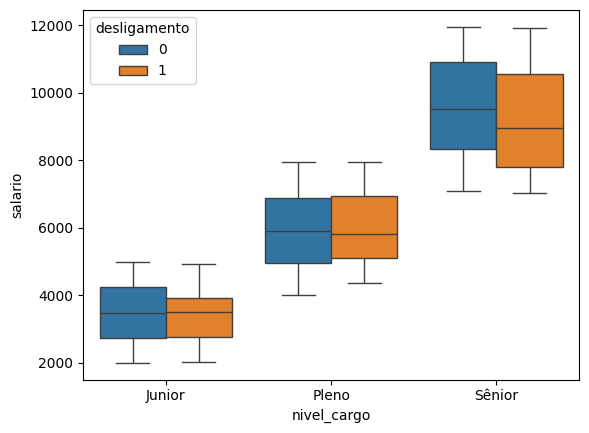

In [51]:
sns.boxplot(data = df_train,
            y = 'salario',
            x = 'nivel_cargo',
            hue = 'desligamento',
            order = ['Junior', 'Pleno', 'Sênior']
            )

In [ ]:
df_train.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento,idade_group,meses_de_servico_group
465,2023-09-17,NaT,8,47,2.006507,1.611548,Sênior,9787.59,10.926578,0,4,1
305,2022-06-24,NaT,23,33,3.964952,4.135056,Sênior,8358.38,18.648868,0,3,3
410,2021-06-29,NaT,35,23,2.004848,1.018990,Junior,3982.97,4.716268,0,1,3
617,2022-12-21,NaT,17,23,2.850331,1.449564,Junior,3764.83,9.719008,0,1,2
172,2023-04-20,NaT,13,48,1.010708,3.027863,Sênior,7513.65,4.816727,0,4,2


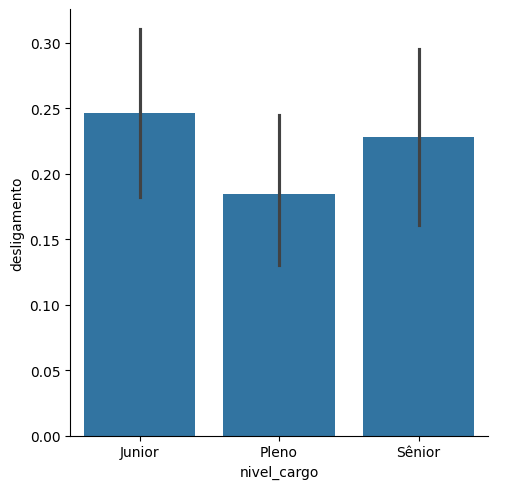

In [52]:
# Quanto maior a idade do funcionário, menor será a taxa de desligamento

sns.catplot(data = df_train,
            x = 'nivel_cargo',
            y = 'desligamento',
            kind = 'bar',
            order = ['Junior', 'Pleno', 'Sênior'])

In [ ]:
taxa_retencao(df_train, by = ['meses_de_servico_group', 'nivel_cargo'])

,meses_de_servico_group,nivel_cargo,total_colaboradores,total_desligamentos,colaboradores_ativos,taxa_retencao,turnover,comparacao_taxa_geral_turnover
0,1,Junior,55,18,37,0.672727,0.986486,26.856240
1,1,Pleno,45,9,36,0.800000,0.750000,-3.554502
2,1,Sênior,40,8,32,0.800000,0.750000,-3.554502
3,2,Junior,51,11,40,0.784314,0.775000,-0.339652
4,2,Pleno,42,8,34,0.809524,0.735294,-5.445591
5,2,Sênior,47,11,36,0.765957,0.805556,3.589609
6,3,Junior,79,14,65,0.822785,0.715385,-8.005833
7,3,Pleno,89,18,71,0.797753,0.753521,-3.101707
8,3,Sênior,72,16,56,0.777778,0.785714,1.038140


<Axes: xlabel='meses_de_servico_group', ylabel='taxa_retencao'>

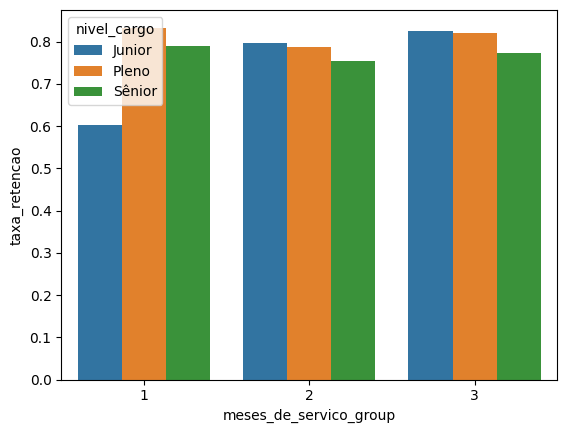

In [53]:
tx_retencao_meses_servico_cargo = taxa_retencao(df_train, by = ['meses_de_servico_group', 'nivel_cargo'])

sns.barplot(data = tx_retencao_meses_servico_cargo,
            x = 'meses_de_servico_group',
            y = 'taxa_retencao',
            hue = 'nivel_cargo')

In [54]:
# quantidade de horas extras x desligamentos

pearson_corr = df_train.corr(numeric_only = True)
spearman_corr = df_train.corr(numeric_only = True, method = 'spearman')

Text(0.5, 1.0, 'Análise de Correlação de Pearson')

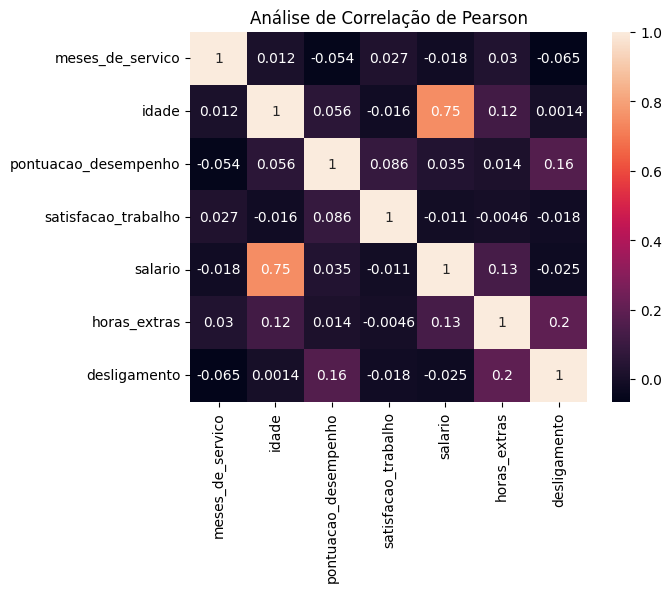

In [55]:
sns.heatmap(data = pearson_corr, annot = True)
plt.title('Análise de Correlação de Pearson')

Text(0.5, 1.0, 'Análise de Correlação de Postos de Spearman')

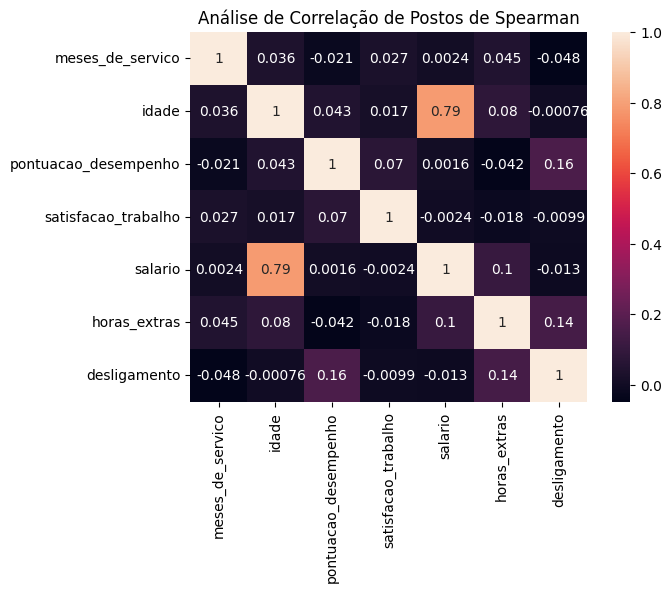

In [ ]:
sns.heatmap(data = spearman_corr, annot = True)
plt.title('Análise de Correlação de Postos de Spearman')

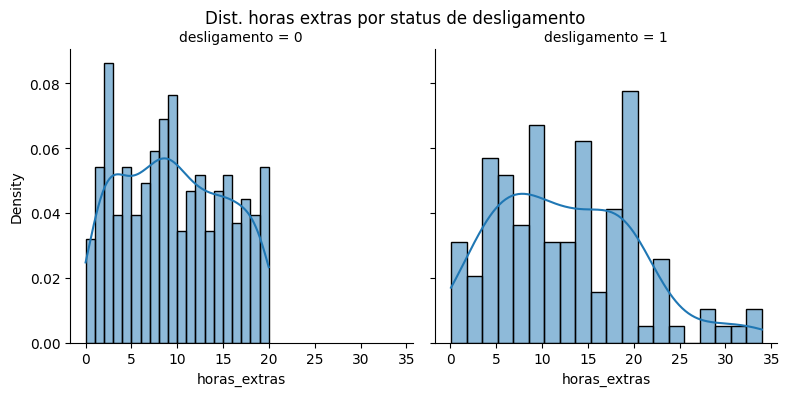

In [56]:
g = sns.FacetGrid(data = df_train, col = 'desligamento', height = 4, aspect = 1)
g.map(sns.histplot, 'horas_extras', bins = 20, stat = 'density', kde = True)

g.figure.subplots_adjust(top=0.88)
g.figure.suptitle('Dist. horas extras por status de desligamento')

plt.show()

<Axes: ylabel='horas_extras'>

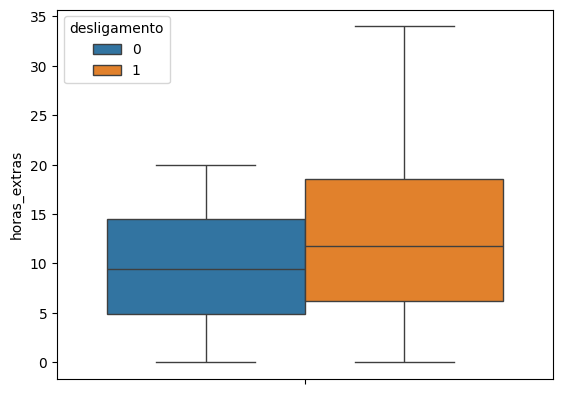

In [57]:
sns.boxplot(data = df_train,
            y = 'horas_extras',
            hue = 'desligamento')

In [ ]:
from scipy.stats import mannwhitneyu

horas_extras_desligamento = df_train.loc[df_train.desligamento == 1].horas_extras
horas_extras_nao_desligamento = df_train.loc[df_train.desligamento == 0].horas_extras

# testando para saber se as distribuicoes sao originarias de uma mesma distruicao

# H0 - a distribuicao de horas extras dos colaboradores desligados é igual a dos não desligados
# H1 - a distribuicao de horas extras dos colaboradores desligados é maior que a dos não desligados
estatistica_u, pvalor = mannwhitneyu(x = horas_extras_desligamento,
             y = horas_extras_nao_desligamento,
             alternative = 'greater')

print('Estatistica U: ', estatistica_u)
print('p-valor: ', pvalor)

Estatistica U:  27571.5
p-valor:  0.0006016156879743249


<Axes: ylabel='salario'>

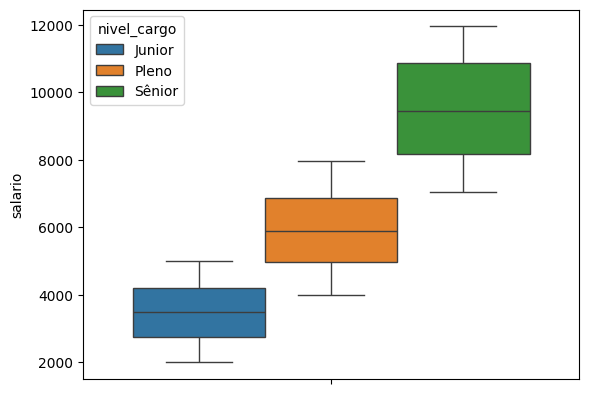

In [58]:
# colaboradores com salario abaixo da média

sns.boxplot(data = df_train, y = 'salario', hue = 'nivel_cargo', hue_order = ['Junior', 'Pleno', 'Sênior'])

<Axes: xlabel='nivel_cargo', ylabel='salario'>

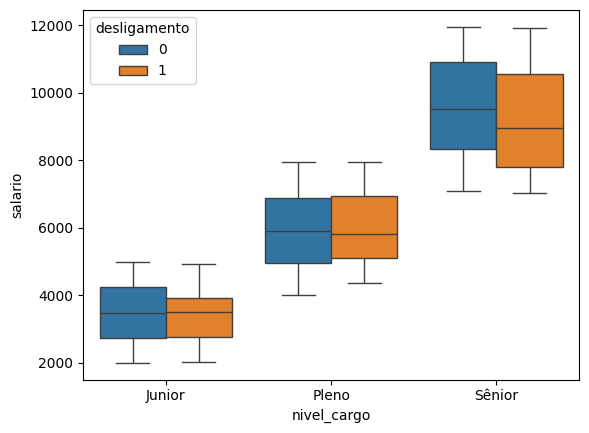

In [59]:
sns.boxplot(data = df_train,
            y = 'salario',
            x = 'nivel_cargo',
            hue = 'desligamento',
            order = ['Junior', 'Pleno', 'Sênior'])

# <font color = 'gold'> Pre Processing </font>

In [ ]:
df.head()

,data_contratacao,data_desligamento,meses_de_servico,idade,pontuacao_desempenho,satisfacao_trabalho,nivel_cargo,salario,horas_extras,desligamento
0,2024-02-14,NaT,3,24,2.066788,2.043644,Pleno,4994.41,15.465241,0
1,2023-11-16,2024-05-14,6,43,3.256257,1.711719,Sênior,8798.34,19.036627,1
2,2023-11-16,NaT,6,45,4.827732,3.480214,Sênior,8891.02,13.326408,0
3,2023-05-20,NaT,12,31,1.453944,1.617558,Pleno,7606.22,14.209663,0
4,2022-07-24,NaT,22,37,2.088917,2.763390,Sênior,9236.03,11.059687,0


In [80]:
train_set, test_set = strat_func(df, version = 2)

df_train = train_set.drop(columns = ['data_contratacao','data_desligamento', 'desligamento', 'idade']).copy() #removendo idade pois ela tem uma correlação alta com salário. Assim vou reduzir a multicolinearidade
df_labels = train_set.desligamento.copy()

In [81]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# creating a combination of new features
class CombiningAttributes(BaseEstimator, TransformerMixin):
    def fit(self, X, y = None):
        return self

    def transform(self, X):
        #X['horas_extras_por_meses_de_servico'] = X.horas_extras / X.meses_de_servico
        #X.drop(columns = 'horas_extras', inplace = True)
        return X

# creating the full pipeline to apply in train set
numeric_features = list(df_train.select_dtypes(include = [np.number]).columns)
cat_features = ['nivel_cargo']

numeric_pipeline = Pipeline([
    ('new_attrib', CombiningAttributes()),
    ('std_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one_hot', OneHotEncoder(sparse_output = False))
])

full_pipeline = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', cat_pipeline, cat_features)
])

df_prepared = full_pipeline.fit_transform(df_train)

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score

lr = LogisticRegression()
lr.fit(X = df_prepared, y = df_labels)

LogisticRegression()

In [83]:
pred = lr.predict(df_prepared)
accuracy = accuracy_score(y_true = df_labels, y_pred = pred)
precision = precision_score(y_true = df_labels, y_pred = pred)

print('Precision: ', precision)

Precision:  0.8


In [84]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator = lr,
                         X = df_prepared,
                         y = df_labels,
                         scoring = 'roc_auc',
                         cv = 10).mean()
scores

0.6162680155210644

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rfc = RandomForestClassifier(random_state = 42)

rodada_1 = {'n_estimators': [5, 10, 20, 30, 50, 100, 200, 300],
            'max_features': [2, 4, 6, 8, 10, 15],
            'criterion': ['entropy']}

rodada_2 = {'n_estimators': [5, 10, 20, 30, 50, 100],
            'max_features': [2, 4, 6, 8, 10, 15],
            'criterion': ['gini']}

rodada_3 = {'max_features': [1,3,10],
            'min_samples_split':[2,3,10],
            'min_samples_leaf':[1,3,10],
            'bootstrap':[False],
            'n_estimators':[100,300],
            'criterion':['gini']}


parametros = [rodada_1, rodada_2, rodada_3]

grid_search = GridSearchCV(estimator = rfc,
                           param_grid = parametros,
                           scoring = 'roc_auc',
                           return_train_score = True,
                           cv = 10)

grid_search.fit(X = df_prepared, y = df_labels)

GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
             param_grid=[{'criterion': ['entropy'],
                          'max_features': [2, 4, 6, 8, 10, 15],
                          'n_estimators': [5, 10, 20, 30, 50, 100, 200, 300]},
                         {'criterion': ['gini'],
                          'max_features': [2, 4, 6, 8, 10, 15],
                          'n_estimators': [5, 10, 20, 30, 50, 100]},
                         {'bootstrap': [False], 'criterion': ['gini'],
                          'max_features': [1, 3, 10],
                          'min_samples_leaf': [1, 3, 10],
                          'min_samples_split': [2, 3, 10],
                          'n_estimators': [100, 300]}],
             return_train_score=True, scoring='roc_auc')

In [73]:
grid_search.best_score_

0.69615022172949

In [76]:
grid_search.best_estimator_

RandomForestClassifier(criterion='entropy', max_features=8, n_estimators=20,
                       random_state=42)

In [74]:
model_selected = grid_search.best_estimator_
grid_search.best_score_

0.69615022172949

In [85]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(criterion='entropy', max_features=8, n_estimators=20,random_state=42)
rfc.fit(X = df_prepared, y = df_labels)

RandomForestClassifier(criterion='entropy', max_features=8, n_estimators=20,
                       random_state=42)

In [105]:
from sklearn.metrics import recall_score, roc_auc_score, classification_report, confusion_matrix
from pycm import ConfusionMatrix

#model_selected = grid_search.best_estimator_
model_selected = rfc

df_test = test_set.drop(columns = ['data_contratacao','data_desligamento', 'desligamento', 'idade', ])
df_labels_test = test_set['desligamento']

df_test_prepared = full_pipeline.transform(df_test)

y_pred = model_selected.predict(df_test_prepared)

precision = precision_score(y_pred = y_pred, y_true = df_labels_test)
roc_auc = roc_auc_score(y_true = df_labels_test, y_score = model_selected.predict_proba(df_test_prepared)[:, 1])

print('Precision: ', precision)
print('Roc Auc: ', roc_auc)
print(15*'----')
print(classification_report(y_true = df_labels_test, y_pred = y_pred))

Precision:  0.7
Roc Auc:  0.6251280300443838
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       101
           1       0.70      0.24      0.36        29

    accuracy                           0.81       130
   macro avg       0.76      0.61      0.62       130
weighted avg       0.79      0.81      0.77       130



In [111]:
confusion_matrix(y_true = df_labels_test, y_pred = y_pred, normalize = 'true') * 100

array([[97.02970297,  2.97029703],
       [75.86206897, 24.13793103]])

In [102]:
cm = ConfusionMatrix(list(df_labels_test), y_pred)
print(cm)

Predict  0        1        
Actual
0        98       3        

1        22       7        





Overall Statistics : 

95% CI                                                            (0.73994,0.87544)
ACC Macro                                                         0.80769
ARI                                                               0.20228
AUNP                                                              0.60584
AUNU                                                              0.60584
Bangdiwala B                                                      0.77784
Bennett S                                                         0.61538
CBA                                                               0.52902
CSI                                                               0.36417
Chi-Squared                                                       14.21759
Chi-Squared DF                                                    1
Conditional Entropy                                          

In [ ]:
c